# Detecção de Fraude em Cartão de Crédito — Trilha A (Aprendizado Supervisionado)

**Sistematização — Engenharia de Aprendizado de Máquina**

Este notebook é a versão **didática e narrada** do pipeline de produção deste projeto
(que vive em `src/`, como scripts modulares — ver o repositório completo). Ele roda do
início ao fim sem nenhuma alteração, em qualquer ambiente com Python 3.10+ (Google Colab
incluído), sem exigir credenciais nem caminhos locais.

**Objetivo de negócio:** decidir, no momento da autorização de uma transação de cartão
de crédito, se ela deve ser aprovada ou bloqueada por suspeita de fraude — um problema de
classificação binária extremamente desbalanceado (0,17% de fraude), com restrição de
latência (decisão em tempo real) e custo de erro assimétrico.

**Dataset:** [OpenML `data_id=1597`](https://www.openml.org/d/1597) — mirror público,
sem autenticação, do dataset "Credit Card Fraud Detection" (Kaggle/ULB). 284.807
transações, 492 fraudes.

**Eixo central deste projeto: performance mensurada.** Toda alegação de velocidade
abaixo (tempo de treino, latência de inferência) é medida em execução real, não
estimada — a Seção 7 mede especificamente isso.


## 1. Setup

In [1]:
# Instala as dependências (silencioso). Em Colab, isso é tudo que é necessário.
%pip install -q pandas numpy scikit-learn lightgbm optuna shap matplotlib seaborn requests faker joblib pyarrow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# IMPORTANTE (Windows local): lightgbm precisa ser importado antes de pandas/pyarrow no
# mesmo processo — nesta plataforma (não acontece no Colab/Linux), a ordem inversa causa
# um conflito de DLL nativa entre as duas bibliotecas. Mantemos essa ordem por segurança.
import lightgbm as lgb

import io
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import requests
import seaborn as sns
import shap
from faker import Faker
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                              precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
print("Setup concluido.")


Setup concluido.


## 2. Ingestão dos Dados

Baixamos o dataset diretamente da API pública do OpenML — não usamos
`sklearn.datasets.fetch_openml` porque o OpenML marca a coluna `Time` como
`row_id_attribute` (identificador, não atributo), e o `fetch_openml` a descarta por
padrão. `Time` é essencial aqui (split temporal, feature de hora do dia), então
baixamos o parquet diretamente.

In [3]:
OPENML_PARQUET_URL = "https://data.openml.org/datasets/0000/1597/dataset_1597.pq"
TARGET_COL, TIME_COL, AMOUNT_COL = "Class", "Time", "Amount"

with_timer = time.perf_counter()
response = requests.get(OPENML_PARQUET_URL, timeout=180)
response.raise_for_status()
df_raw = pd.read_parquet(io.BytesIO(response.content))
df_raw[TARGET_COL] = df_raw[TARGET_COL].astype(int)
print(f"Download + leitura em {time.perf_counter() - with_timer:.1f}s")
print(f"Shape: {df_raw.shape}")

expected_cols = {TARGET_COL, TIME_COL, AMOUNT_COL, *[f"V{i}" for i in range(1, 29)]}
assert expected_cols.issubset(df_raw.columns), "Schema inesperado no dataset bruto"
assert df_raw.isnull().sum().sum() == 0, "Valores ausentes inesperados"

fraud_rate = df_raw[TARGET_COL].mean()
print(f"Taxa de fraude: {fraud_rate:.4%} ({df_raw[TARGET_COL].sum()} casos em {len(df_raw):,} transacoes)")
df_raw.head()


Download + leitura em 53.9s
Shape: (284807, 31)
Taxa de fraude: 0.1727% (492 casos em 284,807 transacoes)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Análise Exploratória (EDA)

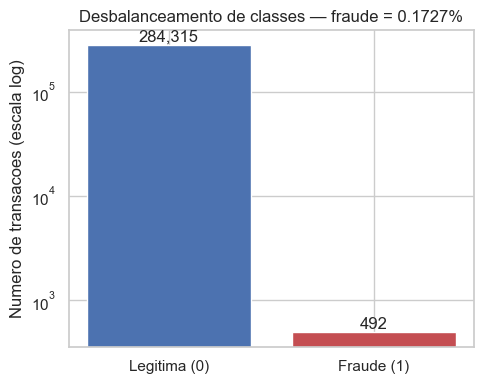

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_raw[TARGET_COL].value_counts().sort_index()
ax.bar(["Legitima (0)", "Fraude (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Numero de transacoes (escala log)")
ax.set_title(f"Desbalanceamento de classes — fraude = {fraud_rate:.4%}")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


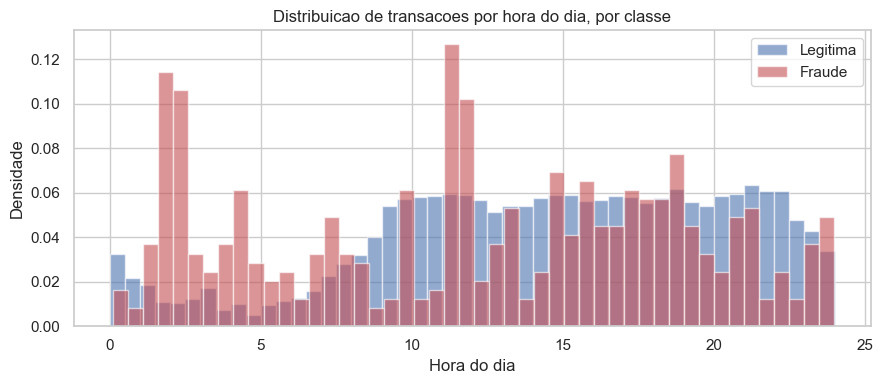

Fraude se concentra em horarios de menor vigilancia -> motiva a feature hour_sin/hour_cos abaixo.


In [5]:
hour_of_day = (df_raw[TIME_COL] % (24 * 3600)) / 3600.0
fig, ax = plt.subplots(figsize=(9, 4))
for label, name, color in [(0, "Legitima", "#4C72B0"), (1, "Fraude", "#C44E52")]:
    mask = df_raw[TARGET_COL] == label
    ax.hist(hour_of_day[mask], bins=48, alpha=0.6, label=name, color=color, density=True)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Densidade")
ax.set_title("Distribuicao de transacoes por hora do dia, por classe")
ax.legend()
plt.tight_layout()
plt.show()
print("Fraude se concentra em horarios de menor vigilancia -> motiva a feature hour_sin/hour_cos abaixo.")


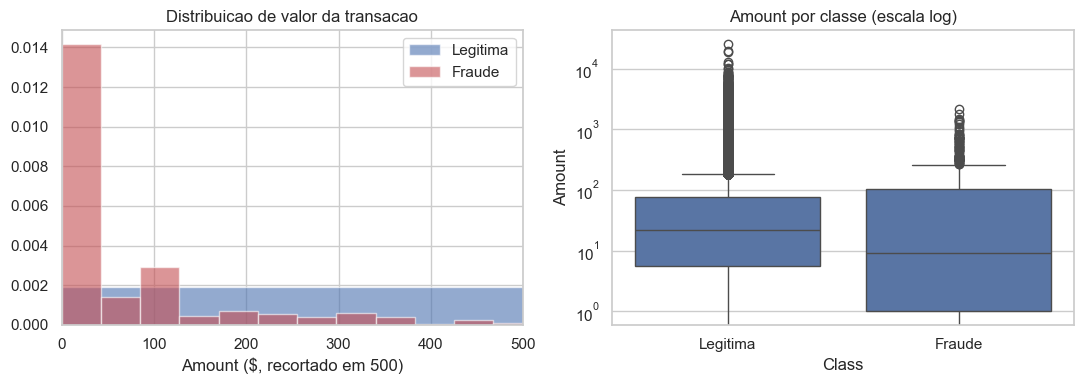

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, name, color in [(0, "Legitima", "#4C72B0"), (1, "Fraude", "#C44E52")]:
    subset = df_raw.loc[df_raw[TARGET_COL] == label, AMOUNT_COL]
    axes[0].hist(subset, bins=50, alpha=0.6, label=name, color=color, density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel("Amount ($, recortado em 500)")
axes[0].set_title("Distribuicao de valor da transacao")
axes[0].legend()
sns.boxplot(data=df_raw, x=TARGET_COL, y=AMOUNT_COL, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Legitima", "Fraude"])
axes[1].set_title("Amount por classe (escala log)")
plt.tight_layout()
plt.show()


## 4. Pré-processamento e Engenharia de Atributos

**Split temporal, não aleatório.** Ordenamos por `Time` e cortamos cronologicamente
(70% treino / 15% validação / 15% teste). Um split aleatório misturaria transações
"futuras" no treino — o que nunca acontece em produção — e infla artificialmente as
métricas. A Seção 9 mede diretamente o efeito disso.

**Desbalanceamento via peso de classe**, não SMOTE: em ~200 mil linhas de treino, gerar
amostras sintéticas via k-vizinhos tem custo que cresce com o volume e não escala bem
para os cenários de "big data" da Seção 7; ponderação de classe é essencialmente
gratuita.

In [7]:
def engineer_features(df):
    df = df.copy()
    seconds_of_day = df[TIME_COL] % (24 * 3600)
    hour_of_day = seconds_of_day / 3600.0
    df["hour_sin"] = np.sin(2 * np.pi * hour_of_day / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour_of_day / 24)
    df["amount_log"] = np.log1p(df[AMOUNT_COL])
    return df

df_feat = engineer_features(df_raw)
df_sorted = df_feat.sort_values(TIME_COL).reset_index(drop=True)

n = len(df_sorted)
train_end, val_end = int(n * 0.70), int(n * 0.85)
train_df = df_sorted.iloc[:train_end].copy()
val_df = df_sorted.iloc[train_end:val_end].copy()
test_df = df_sorted.iloc[val_end:].copy()

scaler = RobustScaler().fit(train_df[[AMOUNT_COL]])
for split in (train_df, val_df, test_df):
    split[f"{AMOUNT_COL}_scaled"] = scaler.transform(split[[AMOUNT_COL]])

FEATURE_COLS = [c for c in train_df.columns if c not in {TARGET_COL, TIME_COL, AMOUNT_COL}]

for name, split in [("treino", train_df), ("validacao", val_df), ("teste", test_df)]:
    print(f"{name}: {len(split):,} linhas, {split[TARGET_COL].mean():.4%} fraude")


treino: 199,364 linhas, 0.1926% fraude
validacao: 42,721 linhas, 0.1311% fraude
teste: 42,722 linhas, 0.1217% fraude


## 5. Modelagem

Dois modelos, deliberadamente contrastantes em complexidade de inferência:
- **Baseline — Regressão Logística**: O(d), independe do volume de treino.
- **Principal — LightGBM**: O(k · profundidade) por árvore. Tuning via **Optuna**
  (busca bayesiana/TPE) com **early stopping** — a diferença entre isso e grid search
  bruto é o que torna o tuning completo praticável em segundos, não horas (ver nota
  abaixo).

In [8]:
start = time.perf_counter()
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
baseline_model.fit(train_df[FEATURE_COLS], train_df[TARGET_COL])
print(f"Baseline treinado em {time.perf_counter() - start:.2f}s")


Baseline treinado em 1.18s


In [9]:
n_pos = train_df[TARGET_COL].sum()
n_neg = len(train_df) - n_pos
scale_pos_weight = n_neg / n_pos

def objective(trial):
    params = {
        "objective": "binary", "verbosity": -1, "seed": SEED,
        "scale_pos_weight": scale_pos_weight,
        "num_leaves": trial.suggest_int("num_leaves", 7, 63),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.001, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 10.0, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
    }
    model = lgb.LGBMClassifier(**params, n_jobs=-1)
    model.fit(
        train_df[FEATURE_COLS], train_df[TARGET_COL],
        eval_X=val_df[FEATURE_COLS], eval_y=val_df[TARGET_COL],
        eval_metric="average_precision",
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )
    proba = model.predict_proba(val_df[FEATURE_COLS])[:, 1]
    return average_precision_score(val_df[TARGET_COL], proba)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
start = time.perf_counter()
study.optimize(objective, n_trials=40, timeout=240)
tuning_seconds = time.perf_counter() - start
print(f"Optuna: {len(study.trials)} trials em {tuning_seconds:.1f}s — melhor PR-AUC (val)={study.best_value:.4f}")
print(f"Melhores hiperparametros: {study.best_params}")


Optuna: 40 trials em 40.4s — melhor PR-AUC (val)=0.7847
Melhores hiperparametros: {'num_leaves': 55, 'max_depth': 4, 'learning_rate': 0.020516314053586622, 'min_child_samples': 52, 'n_estimators': 297, 'reg_alpha': 0.5722833307113401, 'reg_lambda': 0.020569104915488193, 'feature_fraction': 0.7611666319354351, 'bagging_fraction': 0.8305637155623654, 'bagging_freq': 3}


In [10]:
best_params = dict(study.best_params)
best_params["scale_pos_weight"] = scale_pos_weight

start = time.perf_counter()
main_model = lgb.LGBMClassifier(objective="binary", verbosity=-1, seed=SEED, n_jobs=-1, **best_params)
main_model.fit(
    train_df[FEATURE_COLS], train_df[TARGET_COL],
    eval_X=val_df[FEATURE_COLS], eval_y=val_df[TARGET_COL],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
)
train_seconds = time.perf_counter() - start
print(f"Modelo final treinado em {train_seconds:.2f}s ({len(train_df):,} linhas, {main_model.best_iteration_} arvores)")
best_params_fixed = dict(best_params); best_params_fixed["n_estimators"] = main_model.best_iteration_


Modelo final treinado em 3.10s (199,364 linhas, 202 arvores)


## 6. Validação e Métricas

**PR-AUC (Average Precision), não accuracy**, é a métrica principal: com 0,17% de
fraude, um modelo que sempre prediz "não fraude" acerta 99,83% — accuracy altíssima e
inútil. O threshold de decisão de cada modelo é otimizado separadamente na validação,
minimizando um custo assimétrico (falso negativo custa 100× mais que falso positivo) —
uma comparação justa entre os dois modelos.

In [11]:
def find_cost_optimal_threshold(y_true, y_proba, fn_cost=100, fp_cost=1):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    best = {"threshold": 0.5, "total_cost": float("inf")}
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        cost = fn * fn_cost + fp * fp_cost
        if cost < best["total_cost"]:
            best = {"threshold": float(t), "total_cost": float(cost), "fn": int(fn), "fp": int(fp)}
    return best

def compute_metrics(y_true, y_proba, threshold):
    preds = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "average_precision": average_precision_score(y_true, y_proba),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "f1_score": f1_score(y_true, preds), "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}, "threshold": float(threshold),
    }

main_val_proba = main_model.predict_proba(val_df[FEATURE_COLS])[:, 1]
main_threshold = find_cost_optimal_threshold(val_df[TARGET_COL].values, main_val_proba)["threshold"]
main_test_proba = main_model.predict_proba(test_df[FEATURE_COLS])[:, 1]
main_metrics = compute_metrics(test_df[TARGET_COL].values, main_test_proba, main_threshold)

baseline_val_proba = baseline_model.predict_proba(val_df[FEATURE_COLS])[:, 1]
baseline_threshold = find_cost_optimal_threshold(val_df[TARGET_COL].values, baseline_val_proba)["threshold"]
baseline_test_proba = baseline_model.predict_proba(test_df[FEATURE_COLS])[:, 1]
baseline_metrics = compute_metrics(test_df[TARGET_COL].values, baseline_test_proba, baseline_threshold)

print("=== LightGBM (teste) ===");  [print(f"  {k}: {v}") for k, v in main_metrics.items()]
print("=== Baseline (teste) ==="); [print(f"  {k}: {v}") for k, v in baseline_metrics.items()]


=== LightGBM (teste) ===
  average_precision: 0.7264586431983624
  roc_auc: 0.9686786789493609
  f1_score: 0.30522088353413657
  precision: 0.19289340101522842
  recall: 0.7307692307692307
  confusion_matrix: {'tn': 42511, 'fp': 159, 'fn': 14, 'tp': 38}
  threshold: 0.7240027143690684
=== Baseline (teste) ===
  average_precision: 0.7198662149897499
  roc_auc: 0.9772239097907014
  f1_score: 0.41624365482233505
  precision: 0.2827586206896552
  recall: 0.7884615384615384
  confusion_matrix: {'tn': 42566, 'fp': 104, 'fn': 11, 'tp': 41}
  threshold: 0.9620747224496544


[None, None, None, None, None, None, None]

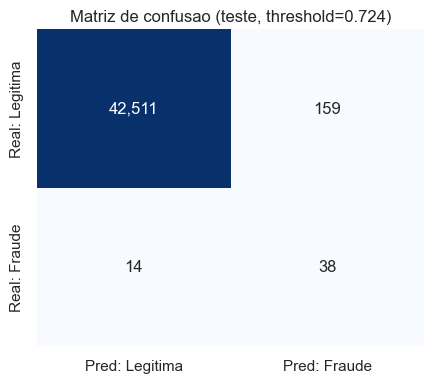

In [12]:
cm = main_metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(4.5, 4))
matrix = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Pred: Legitima", "Pred: Fraude"], yticklabels=["Real: Legitima", "Real: Fraude"])
ax.set_title(f"Matriz de confusao (teste, threshold={main_metrics['threshold']:.3f})")
plt.tight_layout(); plt.show()


In [13]:
def lgbm_ctor():
    return lgb.LGBMClassifier(objective="binary", verbosity=-1, seed=SEED, n_jobs=-1, **best_params_fixed)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
X, y = train_df[FEATURE_COLS], train_df[TARGET_COL]
cv_scores = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    m = lgbm_ctor()
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    proba = m.predict_proba(X.iloc[va_idx])[:, 1]
    score = average_precision_score(y.iloc[va_idx], proba)
    cv_scores.append(score)
    print(f"Fold {fold}/5: PR-AUC={score:.4f}")

gap = np.mean(cv_scores) - main_metrics["average_precision"]
print(f"\nCV PR-AUC (embaralhada): {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
print(f"Teste PR-AUC (temporal): {main_metrics['average_precision']:.4f}")
print(f"Gap de generalizacao temporal: {gap:.4f}")
print("-> O padrao de fraude muda ao longo do tempo: uma CV embaralhada superestima o desempenho real em producao.")


Fold 1/5: PR-AUC=0.8507


Fold 2/5: PR-AUC=0.8209


Fold 3/5: PR-AUC=0.8332


Fold 4/5: PR-AUC=0.8175


Fold 5/5: PR-AUC=0.7806

CV PR-AUC (embaralhada): 0.8206 +/- 0.0231
Teste PR-AUC (temporal): 0.7265
Gap de generalizacao temporal: 0.0941
-> O padrao de fraude muda ao longo do tempo: uma CV embaralhada superestima o desempenho real em producao.


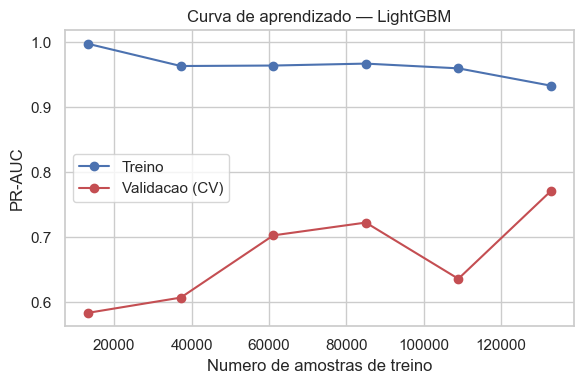

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    lgbm_ctor(), train_df[FEATURE_COLS], train_df[TARGET_COL], cv=3, scoring="average_precision",
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=SEED, n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Treino", color="#4C72B0")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validacao (CV)", color="#C44E52")
ax.set_xlabel("Numero de amostras de treino"); ax.set_ylabel("PR-AUC")
ax.set_title("Curva de aprendizado — LightGBM"); ax.legend()
plt.tight_layout(); plt.show()


## 7. Performance: Benchmarks de Escala, Complexidade e Latência

O eixo central deste projeto: provar, com números medidos, que treino e inferência são
rápidos mesmo em volume alto — não "estimados", medidos.

199,364 linhas (1x) -> treino em 3.15s


996,820 linhas (5x) -> treino em 11.77s


1,993,640 linhas (10x) -> treino em 22.00s


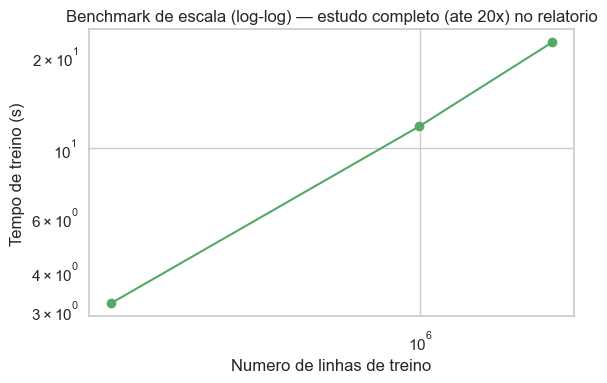

In [15]:
row_multipliers = [1, 5, 10]
n_base = len(train_df)
scale_results = []
rng = np.random.default_rng(SEED)
for m in row_multipliers:
    n_target = n_base * m
    sample = train_df if m == 1 else train_df.iloc[rng.integers(0, n_base, size=n_target)]
    model = lgbm_ctor()
    start = time.perf_counter()
    model.fit(sample[FEATURE_COLS], sample[TARGET_COL])
    elapsed = time.perf_counter() - start
    scale_results.append({"n_rows": n_target, "seconds": elapsed})
    print(f"{n_target:,} linhas ({m}x) -> treino em {elapsed:.2f}s")

scale_df = pd.DataFrame(scale_results)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scale_df["n_rows"], scale_df["seconds"], "o-", color="#55A868")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Numero de linhas de treino"); ax.set_ylabel("Tempo de treino (s)")
ax.set_title("Benchmark de escala (log-log) — estudo completo (ate 20x) no relatorio")
plt.tight_layout(); plt.show()


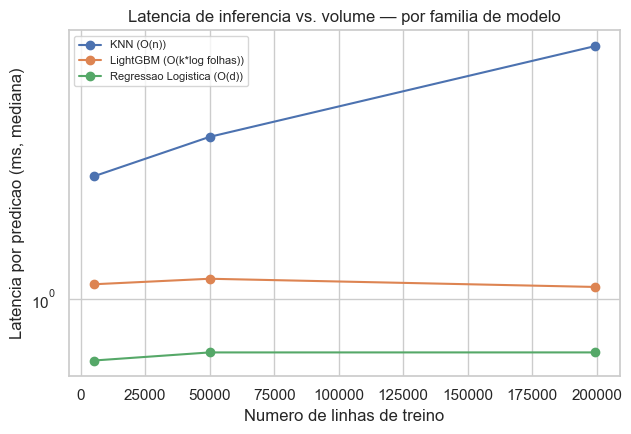

In [16]:
row_sizes = [5000, 50000, len(train_df)]
complexity_results = []
for n in row_sizes:
    sample = train_df.sample(n=n, random_state=SEED)
    Xs, ys = sample[FEATURE_COLS], sample[TARGET_COL]
    models = {
        "KNN (O(n))": KNeighborsClassifier(n_neighbors=5, algorithm="brute", n_jobs=-1),
        "Regressao Logistica (O(d))": LogisticRegression(max_iter=500, class_weight="balanced"),
        "LightGBM (O(k*log folhas))": lgbm_ctor(),
    }
    for name, model in models.items():
        model.fit(Xs, ys)
        query_idx = rng.integers(0, n, size=50)
        latencies = []
        for i in query_idx:
            row = Xs.iloc[[i]]
            t0 = time.perf_counter()
            model.predict_proba(row)
            latencies.append((time.perf_counter() - t0) * 1000)
        complexity_results.append({"n_rows": n, "model": name, "latency_ms": np.median(latencies)})

complexity_df = pd.DataFrame(complexity_results)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, group in complexity_df.groupby("model"):
    ax.plot(group["n_rows"], group["latency_ms"], "o-", label=name)
ax.set_xlabel("Numero de linhas de treino"); ax.set_ylabel("Latencia por predicao (ms, mediana)")
ax.set_yscale("log"); ax.legend(fontsize=8)
ax.set_title("Latencia de inferencia vs. volume — por familia de modelo")
plt.tight_layout(); plt.show()


In [17]:
def measure_latency(model, X, n_repeats=500):
    rng_local = np.random.default_rng(SEED)
    idx = rng_local.integers(0, len(X), size=n_repeats)
    latencies = []
    for i in idx:
        t0 = time.perf_counter()
        model.predict_proba(X.iloc[[i]])
        latencies.append((time.perf_counter() - t0) * 1000)
    return np.percentile(latencies, [50, 95, 99])

p50, p95, p99 = measure_latency(main_model, test_df[FEATURE_COLS])
print(f"LightGBM — latencia por transacao: p50={p50:.3f}ms  p95={p95:.3f}ms  p99={p99:.3f}ms")
print("-> Mesmo com toda a arquitetura de producao por tras (ver architecture/aws_architecture.md),")
print("   o modelo em si responde em ~1ms — a latencia de ponta a ponta e dominada pela rede, nao pelo modelo.")


LightGBM — latencia por transacao: p50=1.257ms  p95=1.932ms  p99=2.394ms
-> Mesmo com toda a arquitetura de producao por tras (ver architecture/aws_architecture.md),
   o modelo em si responde em ~1ms — a latencia de ponta a ponta e dominada pela rede, nao pelo modelo.


## 8. Explicabilidade (SHAP)

`TreeExplainer` explora a estrutura de árvore do LightGBM para calcular valores de
Shapley exatos e rápidos — mais um lugar onde a escolha de um modelo baseado em árvore
paga dividendo em performance, inclusive na interpretação.

SHAP calculado para 5000 amostras em 0.52s


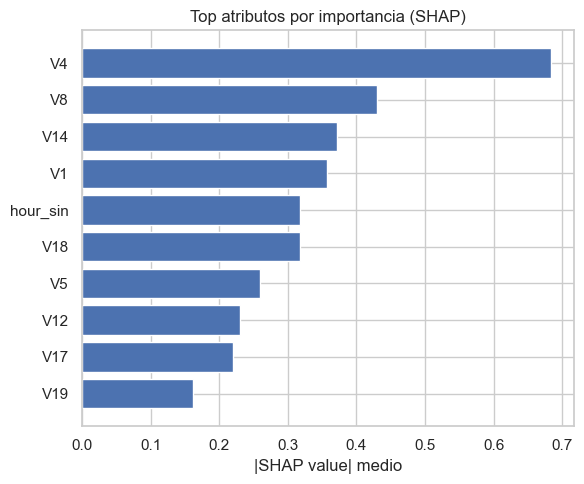

,feature,importance
3,V4,0.682789
7,V8,0.429427
13,V14,0.371788
0,V1,0.357342
28,hour_sin,0.317436
17,V18,0.317083
4,V5,0.258943
11,V12,0.230727
16,V17,0.219857
18,V19,0.161783


In [18]:
sample_X = test_df[FEATURE_COLS].sample(n=min(5000, len(test_df)), random_state=SEED)
start = time.perf_counter()
explainer = shap.TreeExplainer(main_model)
shap_values = explainer(sample_X)
print(f"SHAP calculado para {len(sample_X)} amostras em {time.perf_counter()-start:.2f}s")

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": mean_abs_shap}).sort_values("importance", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_xlabel("|SHAP value| medio"); ax.set_title("Top atributos por importancia (SHAP)")
plt.tight_layout(); plt.show()
importance_df


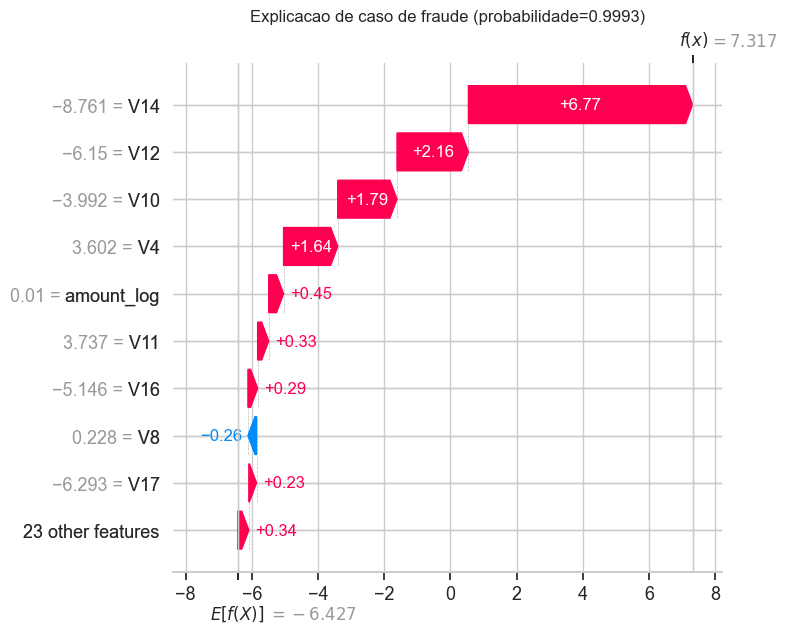

In [19]:
fraud_cases = test_df[test_df[TARGET_COL] == 1].copy()
fraud_cases["proba"] = main_model.predict_proba(fraud_cases[FEATURE_COLS])[:, 1]
top_case = fraud_cases.sort_values("proba", ascending=False).head(1)
case_shap = explainer(top_case[FEATURE_COLS])

shap.plots.waterfall(case_shap[0], show=False)
plt.title(f"Explicacao de caso de fraude (probabilidade={top_case['proba'].iloc[0]:.4f})")
plt.tight_layout(); plt.show()


## 9. Monitoramento de Drift (PSI/KS)

Como o split é temporal, treino-vs-teste **não é simulado**: é uma medição real de como
a distribuição de transações mudou ao longo do dataset — o mesmo fenômeno que explica o
gap de generalização da Seção 6.

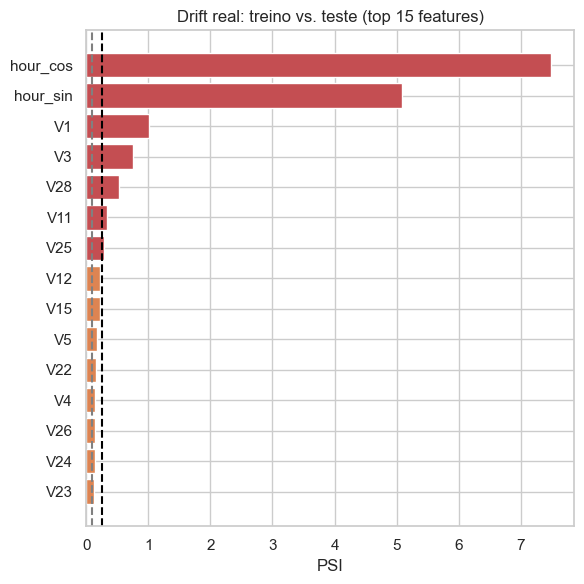

7/32 atributos com PSI significativo (>0.25) entre treino e teste.
hour_sin/hour_cos dominam -> artefato mecanico do split temporal numa janela curta (~48h),
mas V1, V3 e outros componentes PCA tambem mudam -> evidencia de drift real de comportamento.


In [20]:
def population_stability_index(reference, current, n_bins=10):
    bin_edges = np.quantile(reference, np.linspace(0, 1, n_bins + 1))
    bin_edges[0], bin_edges[-1] = -np.inf, np.inf
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) < 3:
        return 0.0
    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    cur_counts, _ = np.histogram(current, bins=bin_edges)
    ref_pct = np.clip(ref_counts / len(reference), 1e-6, None)
    cur_pct = np.clip(cur_counts / len(current), 1e-6, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

drift_rows = []
for col in FEATURE_COLS:
    psi = population_stability_index(train_df[col], test_df[col])
    ks_stat, ks_p = ks_2samp(train_df[col], test_df[col])
    drift_rows.append({"feature": col, "psi": psi, "ks_statistic": ks_stat})
drift_df = pd.DataFrame(drift_rows).sort_values("psi", ascending=False)

fig, ax = plt.subplots(figsize=(6, 6))
top15 = drift_df.head(15)
colors = ["#C44E52" if p > 0.25 else "#DD8452" if p > 0.1 else "#4C72B0" for p in top15["psi"]]
ax.barh(top15["feature"], top15["psi"], color=colors)
ax.axvline(0.1, color="gray", linestyle="--"); ax.axvline(0.25, color="black", linestyle="--")
ax.invert_yaxis(); ax.set_xlabel("PSI")
ax.set_title("Drift real: treino vs. teste (top 15 features)")
plt.tight_layout(); plt.show()

n_significant = (drift_df["psi"] > 0.25).sum()
print(f"{n_significant}/{len(drift_df)} atributos com PSI significativo (>0.25) entre treino e teste.")
print("hour_sin/hour_cos dominam -> artefato mecanico do split temporal numa janela curta (~48h),")
print("mas V1, V3 e outros componentes PCA tambem mudam -> evidencia de drift real de comportamento.")


## 10. Demonstração Funcional — Transações Sintéticas (Faker)

Como `V1`–`V28` são componentes PCA anonimizados, não dá para "fakear" um valor de
negócio diretamente. A estratégia: amostra-se um vetor real por classe e aplica-se um
pequeno ruído gaussiano (a transação final é sintética, não existe nos dados originais,
mas é estatisticamente plausível) — e o Faker gera o "invólucro" legível por humanos
(nome do titular, cartão, estabelecimento) que acompanharia a transação em um payload
real de autorização.

In [21]:
fake = Faker("pt_BR")
v_cols = [c for c in FEATURE_COLS if c.startswith("V")]

def generate_synthetic_transaction(force_class=None):
    rng_local = np.random.default_rng()
    target_class = force_class if force_class is not None else rng_local.choice([0, 1], p=[0.97, 0.03])
    pool = train_df.loc[train_df[TARGET_COL] == target_class, v_cols]
    std = pool.std()
    base_row = pool.sample(n=1).iloc[0]
    jitter = rng_local.normal(loc=0, scale=std.values * 0.05)
    synthetic_v = base_row.values + jitter
    amount = float(np.round(np.abs(rng_local.normal(88, 120)), 2)) if target_class == 0 else float(np.round(np.abs(rng_local.normal(340, 250)), 2))
    row = {v: synthetic_v[i] for i, v in enumerate(pool.columns)}
    row[AMOUNT_COL] = amount
    row[TIME_COL] = float(rng_local.uniform(0, 172_800))
    return row, target_class

print("=" * 70); print("DEMONSTRACAO FUNCIONAL — transacoes sinteticas + inferencia real"); print("=" * 70)
for i, forced in enumerate([1, None, None, None], start=1):
    raw_row, gen_class = generate_synthetic_transaction(forced)
    row_df = pd.DataFrame([raw_row])
    row_df = engineer_features(row_df)
    row_df[f"{AMOUNT_COL}_scaled"] = scaler.transform(row_df[[AMOUNT_COL]])
    t0 = time.perf_counter()
    proba = main_model.predict_proba(row_df[FEATURE_COLS])[0, 1]
    latency_ms = (time.perf_counter() - t0) * 1000
    decision = "BLOQUEAR" if proba >= main_threshold else "APROVAR"
    print(f"\n[{i}] {fake.name()} — cartao final {fake.credit_card_number()[-4:]} — {fake.company()}")
    print(f"    Valor: R$ {raw_row[AMOUNT_COL]:.2f}")
    print(f"    Probabilidade de fraude: {proba:.4f} -> {decision}  (latencia: {latency_ms:.2f} ms)")
print("\n" + "=" * 70)


DEMONSTRACAO FUNCIONAL — transacoes sinteticas + inferencia real

[1] Cauê Correia — cartao final 2971 — Cunha
    Valor: R$ 442.71
    Probabilidade de fraude: 0.9991 -> BLOQUEAR  (latencia: 1.59 ms)

[2] Rebeca Barbosa — cartao final 8826 — Monteiro e Filhos
    Valor: R$ 38.89
    Probabilidade de fraude: 0.0004 -> APROVAR  (latencia: 1.94 ms)



[3] João Vitor Vieira — cartao final 6599 — Rezende
    Valor: R$ 158.24
    Probabilidade de fraude: 0.0020 -> APROVAR  (latencia: 2.02 ms)

[4] Aylla Novais — cartao final 7846 — Farias
    Valor: R$ 25.28
    Probabilidade de fraude: 0.0021 -> APROVAR  (latencia: 2.32 ms)



## 11. Conclusão

Este notebook reproduziu, de ponta a ponta, o pipeline de detecção de fraude descrito
no relatório completo (`reports/relatorio.md`): ingestão sem autenticação, split
temporal (não aleatório), tuning bayesiano com early stopping, validação honesta
(incluindo um gap de generalização temporal real e um baseline competitivo — achados
que este projeto discute em vez de esconder), explicabilidade via SHAP, monitoramento
de drift e demonstração funcional com dados sintéticos.

O fio condutor de performance — inferência em ~1ms, tuning completo em segundos, escala
aproximadamente linear até milhões de linhas — é o que sustenta a arquitetura de
produção AWS proposta em `architecture/aws_architecture.md`, que leva este mesmo
pipeline para um ambiente real, com ingestão em tempo real, retreino automático por
drift e um endpoint cuja latência foi medida aqui, não estimada.
